# Logistic Regression – Lung Cancer Survival Prediction
**Problem:** binary classification – predict `survived` (1 = survived, 0 = did not survive).
**Model:** Logistic Regression (scikit-learn)

Sections: 1 Load · 2 Split · 3 Model varieties · 4 Hyperparameter tuning · 5 Comparison · 6 Final model plots · 7 Conclusion

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the preprocessed data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PATH = '/content/drive/MyDrive/AI_final/lung_cancer_processed.csv'

import pandas as pd, numpy as np, time, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

df = pd.read_csv(PATH)
X = df.drop(columns='survived'); y = df['survived']
print(df.shape); print(y.value_counts(normalize=True).round(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(886105, 22)
survived
0    0.78
1    0.22
Name: proportion, dtype: float64


## 2. Stratified train/test split
`stratify=y` keeps the 78/22 class ratio in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (708884, 21) | Test: (177221, 21)


## 3. Model varieties
Logistic Regression is a **linear** model, so it is sensitive to how features are encoded and scaled. Two issues in the processed file matter:
- `country` is label-encoded (0–26), which wrongly implies an order → **one-hot encode it** for this model.
- `diagnosis_year` (2014–2024) is not scaled → **standardize it** (scaler fitted on the training set only).

| Variety | What changes |
|---|---|
| A – Baseline | default Logistic Regression on the file as is |
| B – Class weights | `class_weight='balanced'` |
| C – Improved preprocessing | B + one-hot `country` + scaled `diagnosis_year` |
| D – Tuned | hyperparameters from GridSearchCV on C's features (section 4) |
| Baseline | random-guess `DummyClassifier` for reference |

**Metrics:** ROC-AUC and PR-AUC (do not depend on the decision threshold), plus precision / recall / F1 of the *survived* class. Accuracy alone is misleading (predicting "died" for everyone gives ~78%).

In [ ]:
results, models = {}, {}

def evaluate(name, model, Xtr, Xte):
    t = time.time(); model.fit(Xtr, y_train); secs = time.time() - t
    pred = model.predict(Xte); proba = model.predict_proba(Xte)[:, 1]
    results[name] = {'Accuracy': accuracy_score(y_test, pred),
                     'Precision': precision_score(y_test, pred, zero_division=0),
                     'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
                     'ROC-AUC': roc_auc_score(y_test, proba),
                     'PR-AUC': average_precision_score(y_test, proba),
                     'Train time (s)': secs}
    models[name] = (model, Xte)
    print(name, '->', {k: round(float(v), 3) for k, v in results[name].items()})

# A - baseline
evaluate('A: Baseline', LogisticRegression(max_iter=1000), X_train, X_test)

# B - class weights
evaluate('B: Class weights', LogisticRegression(max_iter=1000, class_weight='balanced'), X_train, X_test)

A: Baseline -> {'Accuracy': 0.78, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC-AUC': 0.499, 'PR-AUC': 0.218, 'Train time (s)': 12.707}
B: Class weights -> {'Accuracy': 0.499, 'Precision': 0.22, 'Recall': 0.502, 'F1': 0.306, 'ROC-AUC': 0.499, 'PR-AUC': 0.218, 'Train time (s)': 23.62}


In [ ]:
# C - improved preprocessing: one-hot country + scale diagnosis_year
def prep(Xtr, Xte):
    Xtr, Xte = Xtr.copy(), Xte.copy()
    both = pd.concat([Xtr.assign(_s='tr'), Xte.assign(_s='te')])
    both = pd.get_dummies(both, columns=['country'], prefix='country', drop_first=True, dtype=int)
    Xtr, Xte = both[both['_s']=='tr'].drop(columns='_s'), both[both['_s']=='te'].drop(columns='_s')
    sc = StandardScaler().fit(Xtr[['diagnosis_year']])          # fit on train only
    Xtr['diagnosis_year'] = sc.transform(Xtr[['diagnosis_year']])
    Xte['diagnosis_year'] = sc.transform(Xte[['diagnosis_year']])
    return Xtr, Xte

X_train_c, X_test_c = prep(X_train, X_test)
print('Features after preprocessing:', X_train_c.shape[1])
evaluate('C: Better preprocessing', LogisticRegression(max_iter=1000, class_weight='balanced'), X_train_c, X_test_c)

Features after preprocessing: 46
C: Better preprocessing -> {'Accuracy': 0.494, 'Precision': 0.221, 'Recall': 0.511, 'F1': 0.308, 'ROC-AUC': 0.5, 'PR-AUC': 0.219, 'Train time (s)': 1.541}


## 4. Hyperparameter tuning (GridSearchCV)
Tuned on a 100k sample with **stratified 3-fold cross-validation**, optimizing **ROC-AUC** (it does not depend on the decision threshold, unlike F1).
- `C` – inverse regularization strength (smaller = stronger regularization)
- `penalty` – L1 (can zero out features) or L2
- `class_weight` – none or balanced

In [ ]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10],
              'penalty': ['l1', 'l2'],
              'class_weight': [None, 'balanced']}

sub = X_train_c.sample(100_000, random_state=1)
grid = GridSearchCV(LogisticRegression(solver='liblinear', max_iter=1000), param_grid,
                    scoring='roc_auc', cv=StratifiedKFold(3, shuffle=True, random_state=42), verbose=1)
grid.fit(sub, y_train.loc[sub.index])
print('Best params:', grid.best_params_)
print('Best CV ROC-AUC:', round(grid.best_score_, 4))
pd.DataFrame(grid.cv_results_)[['params','mean_test_score','rank_test_score']].sort_values('rank_test_score').head(5)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2'}
Best CV ROC-AUC: 0.5056


,params,mean_test_score,rank_test_score
19,"{'C': 10, 'class_weight': 'balanced', 'penalty...",0.505616,1
15,"{'C': 1, 'class_weight': 'balanced', 'penalty'...",0.505607,2
18,"{'C': 10, 'class_weight': 'balanced', 'penalty...",0.505605,3
17,"{'C': 10, 'class_weight': None, 'penalty': 'l2'}",0.505570,4
11,"{'C': 0.1, 'class_weight': 'balanced', 'penalt...",0.505540,5


In [ ]:
evaluate('D: Tuned', LogisticRegression(solver='liblinear', max_iter=1000, **grid.best_params_), X_train_c, X_test_c)

# Random-guess baseline for reference
dummy = DummyClassifier(strategy='stratified', random_state=42).fit(X_train_c, y_train)
evaluate('Random-guess baseline', dummy, X_train_c, X_test_c)

D: Tuned -> {'Accuracy': 0.494, 'Precision': 0.221, 'Recall': 0.514, 'F1': 0.309, 'ROC-AUC': 0.5, 'PR-AUC': 0.219, 'Train time (s)': 3.505}
Random-guess baseline -> {'Accuracy': 0.657, 'Precision': 0.22, 'Recall': 0.22, 'F1': 0.22, 'ROC-AUC': 0.5, 'PR-AUC': 0.22, 'Train time (s)': 0.008}


## 5. Comparison of varieties

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train time (s)
A: Baseline,0.7798,0.0000,0.0000,0.0000,0.4991,0.2184,12.7069
B: Class weights,0.4988,0.2201,0.5018,0.3060,0.4992,0.2185,23.6196
C: Better preprocessing,0.4944,0.2205,0.5113,0.3081,0.4998,0.2193,1.5411
D: Tuned,0.4937,0.2209,0.5139,0.3090,0.4999,0.2193,3.5048
Random-guess baseline,0.6566,0.2201,0.2200,0.2200,0.4999,0.2202,0.0080


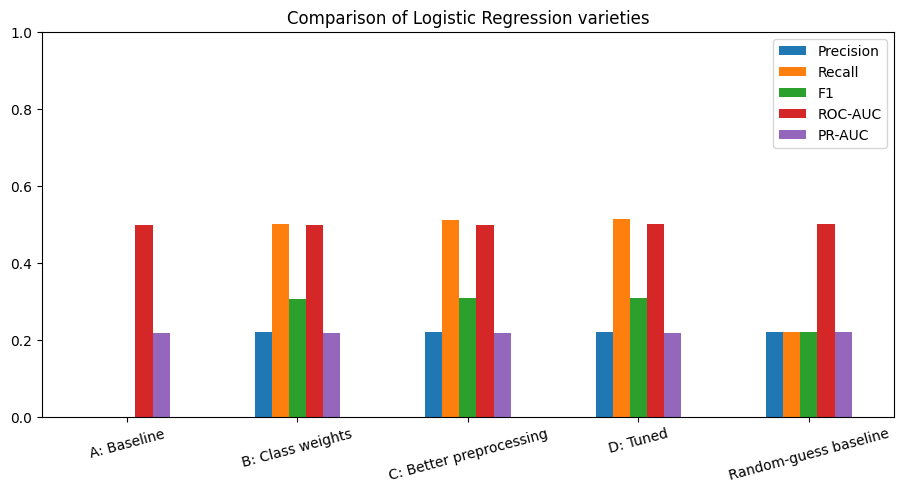

In [ ]:
comp = pd.DataFrame(results).T.round(4)
display(comp)
comp[['Precision','Recall','F1','ROC-AUC','PR-AUC']].plot.bar(figsize=(11,5))
plt.title('Comparison of Logistic Regression varieties'); plt.xticks(rotation=15); plt.ylim(0, 1); plt.show()

In [ ]:
# Validation method: stratified 5-fold cross-validation of the tuned model (ROC-AUC)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
idx = X_train_c.sample(100_000, random_state=3).index
s = cross_val_score(LogisticRegression(solver='liblinear', max_iter=1000, **grid.best_params_),
                    X_train_c.loc[idx], y_train.loc[idx], cv=cv, scoring='roc_auc')
print('5-fold ROC-AUC:', s.round(4), '| mean =', s.mean().round(4), '| std =', s.std().round(4))

5-fold ROC-AUC: [0.5076 0.4967 0.5075 0.5012 0.5029] | mean = 0.5032 | std = 0.0041


## 6. Final model – confusion matrix, ROC curve, coefficients

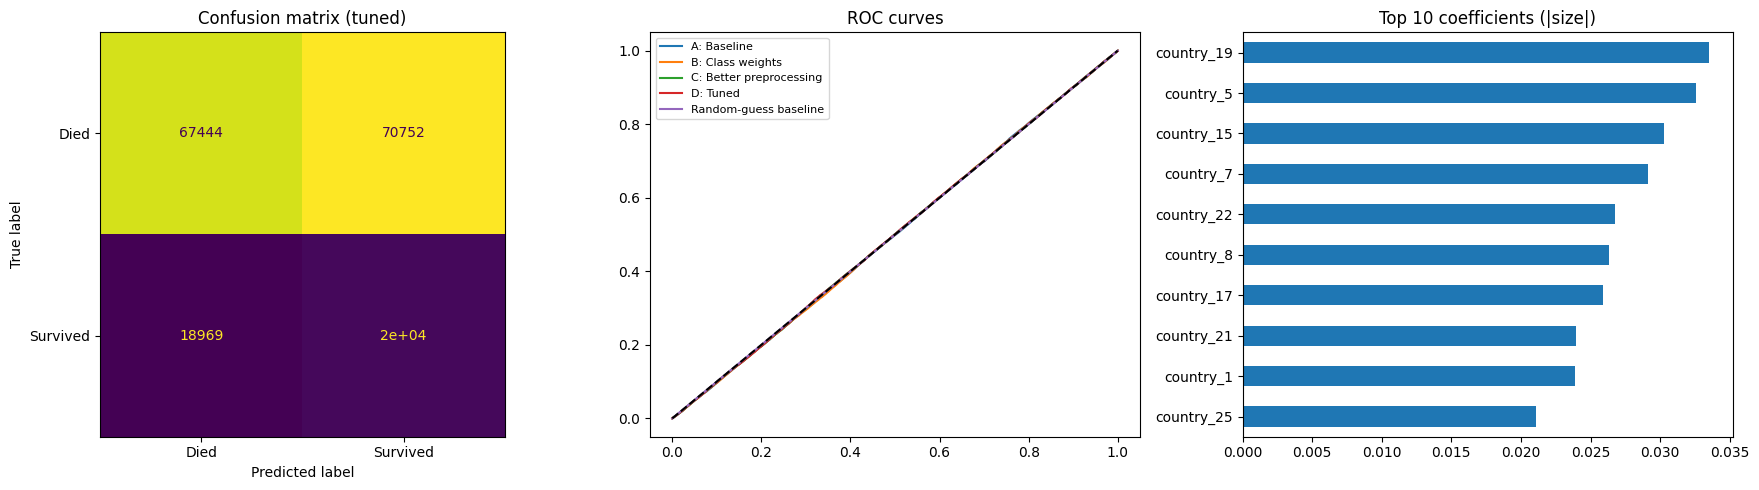

              precision    recall  f1-score   support

        Died       0.78      0.49      0.60    138196
    Survived       0.22      0.51      0.31     39025

    accuracy                           0.49    177221
   macro avg       0.50      0.50      0.45    177221
weighted avg       0.66      0.49      0.54    177221



In [ ]:
model, Xte = models['D: Tuned']
pred = model.predict(Xte)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['Died','Survived']).plot(ax=ax[0], colorbar=False)
ax[0].set_title('Confusion matrix (tuned)')
for n, (m, xt) in models.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(xt)[:, 1]); ax[1].plot(fpr, tpr, label=n)
ax[1].plot([0,1],[0,1],'k--'); ax[1].set_title('ROC curves'); ax[1].legend(fontsize=8)
coef = pd.Series(model.coef_[0], index=Xte.columns)
coef.reindex(coef.abs().sort_values().tail(10).index).plot.barh(ax=ax[2]); ax[2].set_title('Top 10 coefficients (|size|)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, pred, target_names=['Died','Survived']))

## 7. Conclusion
- **Why Logistic Regression:** suits a binary target, is fast on 886k rows, gives probabilities, and its coefficients are interpretable (direction and size of each feature's effect). Regularization (`C`, L1/L2) controls overfitting.
- **Preprocessing matters for a linear model:** one-hot encoding `country` and scaling `diagnosis_year` removes the false ordering and scale problems (variety C vs B).
- **Imbalance:** without class weights the model predicts almost only "died" (high accuracy, near-zero recall).
- **Comparison:** state which variety had the best ROC-AUC / PR-AUC and compare it with the random-guess baseline.
- **Limitations:** ROC-AUC ≈ 0.50 for every variety, equal to random guessing, because all features have near-zero correlation with `survived`; the data appears synthetic. Any F1 gain comes from predicting "survived" more often (recall rises, precision stays at the 22% base rate), not from learning.
- **Improvements:** more informative features, polynomial/interaction terms, non-linear models (Random Forest, XGBoost), or real clinical data.